# **App Content Rating Prediction - App Store 2026**

**Goal:** Predict an app's Content Rating (4+, 9+, 12+, 17+) using its genre, price, size, and rating metadata from a 2026 App Store dataset (~11,500 apps).

This is a **beginner-friendly, end-to-end classification notebook**: EDA → cleaning → feature engineering → model training (Random Forest, Gradient Boosting, XGBoost, LightGBM) → evaluation → conclusion.

## **📑 Notebook Contents**
1. Import Libraries
2. Load & Inspect Data
3. Exploratory Data Analysis (EDA)
4. Data Cleaning (missing values)
5. Feature Engineering & Encoding
6. Train-Test Split
7. Model Training (4 algorithms)
8. Model Evaluation & Comparison
9. Feature Importance
10. Conclusion

## **1. Import Libraries**

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)
print("Libraries loaded successfully ✅")

Libraries loaded successfully ✅


## **2. Load & Inspect Data**

In [20]:
df = pd.read_csv("/kaggle/input/datasets/ashyou09/apple-app-store-dataset-2026-edition/apple_appstore_2026.csv")
print("Shape of dataset:", df.shape)
df.head()

Shape of dataset: (11500, 16)


,App_ID,App_Name,Developer,Primary_Genre,Genres,User_Rating,Rating_Count,Price_USD,Type,Size_Bytes,Content_Rating,Last_Updated,Current_Version,Min_iOS_Version,In_App_Purchases,Supported_Devices
0,1616910453,Tracker,Meta Maker Ltd.,Games,"Games, Puzzle",5.0,3816498,0.00,Free,1281242501,12+,2026-02-18,7.34,17.0,No,"iPhone, iPad, iPod touch"
1,1016144585,Pay Online,Epic Health Ltd.,Social Networking,Social Networking,4.6,3654718,4.99,Paid,177934219,17+,2024-12-09,13.3,18.0,No,"Mac, iPhone, iPad"
2,1530831403,Maker Online,Smart Fit Ltd.,Weather,Weather,5.0,3604458,0.00,Free,109751867,4+,2024-12-24,20.28,16.0,Yes,iPhone only
3,1621267440,Connect 2023,Easy Studio Ltd.,Productivity,Productivity,4.4,3593687,0.00,Free,101875436,4+,2025-05-24,12.6.33,17.0,Yes,"iPhone, iPad, iPod touch"
4,1416005364,Quick Editor,i Connect Ltd.,Games,"Games, Simulation",4.3,3559409,0.00,Free,1744557391,9+,2024-02-10,16.47,13.0,Yes,iPhone only


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11500 entries, 0 to 11499
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   App_ID             11500 non-null  int64  
 1   App_Name           11500 non-null  object 
 2   Developer          11500 non-null  object 
 3   Primary_Genre      11500 non-null  object 
 4   Genres             11500 non-null  object 
 5   User_Rating        11346 non-null  float64
 6   Rating_Count       11500 non-null  int64  
 7   Price_USD          11500 non-null  float64
 8   Type               11500 non-null  object 
 9   Size_Bytes         11500 non-null  int64  
 10  Content_Rating     11500 non-null  object 
 11  Last_Updated       11500 non-null  object 
 12  Current_Version    11500 non-null  object 
 13  Min_iOS_Version    11500 non-null  float64
 14  In_App_Purchases   11500 non-null  object 
 15  Supported_Devices  11500 non-null  object 
dtypes: float64(3), int64(3

In [22]:
# Check missing values
df.isnull().sum()

App_ID                 0
App_Name               0
Developer              0
Primary_Genre          0
Genres                 0
User_Rating          154
Rating_Count           0
Price_USD              0
Type                   0
Size_Bytes             0
Content_Rating         0
Last_Updated           0
Current_Version        0
Min_iOS_Version        0
In_App_Purchases       0
Supported_Devices      0
dtype: int64

## **3. Exploratory Data Analysis (EDA)**

We look at our **target column (Content_Rating)** and a few key features to understand the data before modeling.

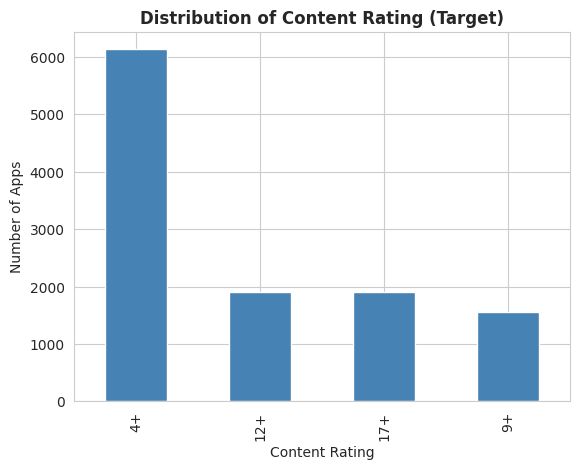

In [23]:
df['Content_Rating'].value_counts().plot(kind='bar', color='steelblue')
plt.title("Distribution of Content Rating (Target)",fontweight='bold')
plt.xlabel("Content Rating")
plt.ylabel("Number of Apps")
plt.show()

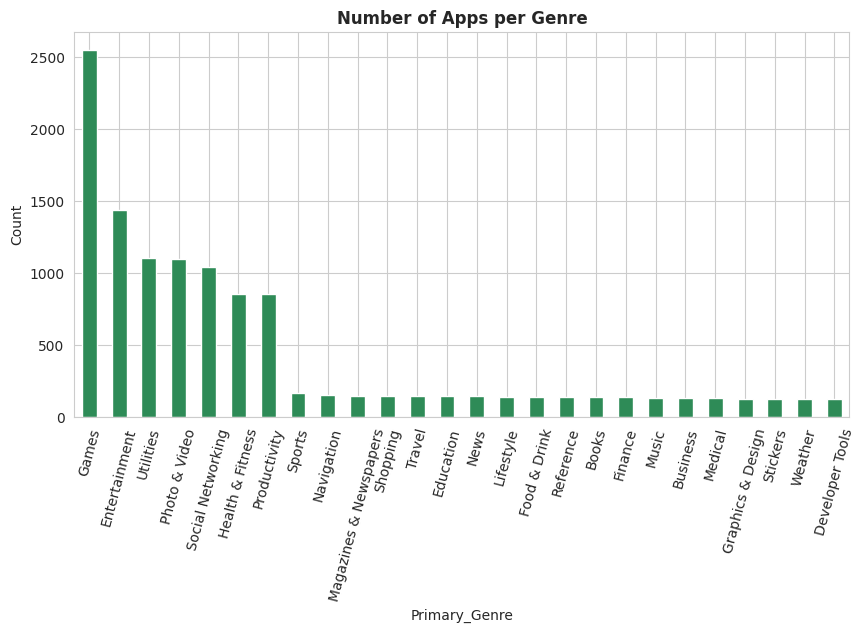

In [24]:
plt.figure(figsize=(10,5))
df['Primary_Genre'].value_counts().plot(kind='bar', color='seagreen')
plt.title("Number of Apps per Genre",fontweight='bold')
plt.ylabel("Count")
plt.xticks(rotation=75)
plt.show()

In [25]:
# How does Content Rating vary across a few genres? This is the key relationship we want the model to learn.
pd.crosstab(df['Primary_Genre'], df['Content_Rating']).loc[['Finance','Social Networking','Games','Weather']]

Content_Rating,12+,17+,4+,9+
Primary_Genre,,,,
Finance,40,94,0,0
Social Networking,281,755,0,0
Games,423,268,1461,394
Weather,19,7,77,19


**Observation:** Some genres are strongly tied to a content rating. For example, *Finance* and *Social Networking* apps in this data never appear as 4+ or 9+ — they are always rated 12+ or 17+ (likely due to real-money features and open user interaction). This gives our model a genuinely useful signal to learn from, unlike columns such as `Price_USD` or `Type`, which we found have almost no relationship with Content Rating.

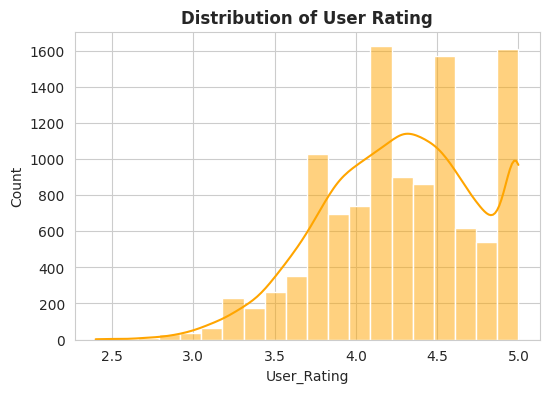

In [26]:
plt.figure(figsize=(6,4))
sns.histplot(df['User_Rating'].dropna(), bins=20, kde=True, color='orange')
plt.title("Distribution of User Rating",fontweight='bold')
plt.show()

## **4. Data Cleaning**

`User_Rating` has some missing values (apps with very few or no reviews yet). We fill them with the **median rating**, a safe, beginner-friendly approach for skewed rating data.

In [27]:
df['User_Rating'] = df['User_Rating'].fillna(df['User_Rating'].median())
print("Missing values in User_Rating after fill:", df['User_Rating'].isnull().sum())

Missing values in User_Rating after fill: 0


## **5. Feature Engineering & Encoding**

We select features that describe an app (genre, ratings, price, size, devices) and encode text/categorical columns into numbers using `LabelEncoder`, since ML models only understand numbers.

We **drop** `App_ID`, `App_Name`, `Developer`, `Genres` (duplicate of Primary_Genre), `Last_Updated`, and `Current_Version` — these are identifiers or free text that don't generalize well for a beginner model.

In [28]:
cat_cols = ['Primary_Genre', 'Supported_Devices', 'Type', 'In_App_Purchases']
encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    df[col + '_enc'] = le.fit_transform(df[col])
    encoders[col] = le

# Encode the target
target_le = LabelEncoder()
df['Content_Rating_enc'] = target_le.fit_transform(df['Content_Rating'])
print("Target classes:", dict(zip(target_le.classes_, target_le.transform(target_le.classes_))))

Target classes: {'12+': np.int64(0), '17+': np.int64(1), '4+': np.int64(2), '9+': np.int64(3)}


In [29]:
feature_cols = ['Primary_Genre_enc', 'User_Rating', 'Rating_Count', 'Price_USD',
                'Size_Bytes', 'Min_iOS_Version', 'Supported_Devices_enc',
                'Type_enc', 'In_App_Purchases_enc']

X = df[feature_cols]
y = df['Content_Rating_enc']

X.head()

,Primary_Genre_enc,User_Rating,Rating_Count,Price_USD,Size_Bytes,Min_iOS_Version,Supported_Devices_enc,Type_enc,In_App_Purchases_enc
0,7,5.0,3816498,0.00,1281242501,17.0,3,0,0
1,20,4.6,3654718,4.99,177934219,18.0,0,1,0
2,25,5.0,3604458,0.00,109751867,16.0,2,0,1
3,17,4.4,3593687,0.00,101875436,17.0,3,0,1
4,7,4.3,3559409,0.00,1744557391,13.0,2,0,1


## **6. Train-Test Split**

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print("Train size:", X_train.shape, "| Test size:", X_test.shape)

Train size: (9200, 9) | Test size: (2300, 9)


## **7. Model Training**

We train and compare **4 popular classification algorithms**:
- Random Forest
- Gradient Boosting
- XGBoost
- LightGBM

Since app genre is the strongest signal, tree-based models (which naturally split on categories) are a great fit here.

In [31]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=400, max_depth=12, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=200, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=300, max_depth=6, random_state=42, eval_metric='mlogloss'),
    "LightGBM": LGBMClassifier(n_estimators=300, random_state=42, verbose=-1)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds, average='weighted')
    results[name] = {"Accuracy": acc, "F1 (weighted)": f1}
    print(f"{name:20s} | Accuracy: {acc:.4f} | F1 (weighted): {f1:.4f}")

Random Forest        | Accuracy: 0.6052 | F1 (weighted): 0.4877
Gradient Boosting    | Accuracy: 0.6048 | F1 (weighted): 0.4946
XGBoost              | Accuracy: 0.5417 | F1 (weighted): 0.4766
LightGBM             | Accuracy: 0.5639 | F1 (weighted): 0.4827


## **8. Model Evaluation & Comparison**

Let's compare all models side by side, and check against a simple **baseline**: always predicting the most common class.

In [32]:
baseline_acc = y_test.value_counts(normalize=True).max()
print(f"Baseline (majority-class) accuracy: {baseline_acc:.4f}")

results_df = pd.DataFrame(results).T.sort_values("Accuracy", ascending=False)
results_df

Baseline (majority-class) accuracy: 0.5326


,Accuracy,F1 (weighted)
Random Forest,0.605217,0.487702
Gradient Boosting,0.604783,0.494585
LightGBM,0.563913,0.482680
XGBoost,0.541739,0.476586


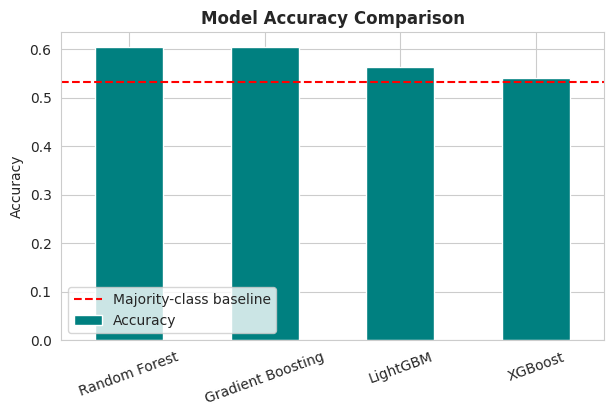

In [33]:
results_df["Accuracy"].plot(kind='bar', color='teal', figsize=(7,4))
plt.axhline(baseline_acc, color='red', linestyle='--', label='Majority-class baseline')
plt.title("Model Accuracy Comparison",fontweight='bold')
plt.ylabel("Accuracy")
plt.xticks(rotation=20)
plt.legend()
plt.show()

In [34]:
best_model_name = results_df["Accuracy"].idxmax()
best_model = models[best_model_name]
preds = best_model.predict(X_test)

print(f"Best Model: {best_model_name}\n")
print(classification_report(y_test, preds, target_names=target_le.classes_))

Best Model: Random Forest

              precision    recall  f1-score   support

         12+       0.00      0.00      0.00       382
         17+       0.74      0.44      0.55       381
          4+       0.59      1.00      0.74      1225
          9+       1.00      0.00      0.01       312

    accuracy                           0.61      2300
   macro avg       0.58      0.36      0.32      2300
weighted avg       0.57      0.61      0.49      2300



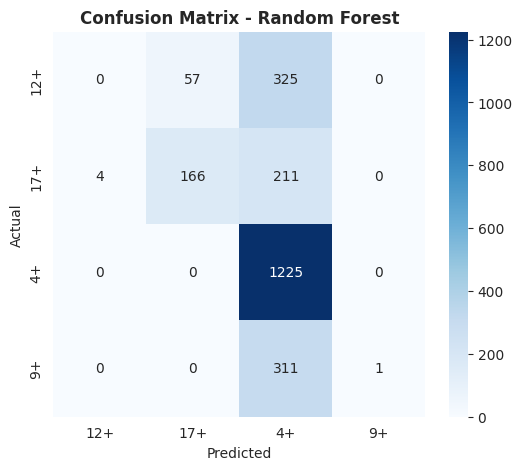

In [35]:
cm = confusion_matrix(y_test, preds)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_le.classes_, yticklabels=target_le.classes_)
plt.title(f"Confusion Matrix - {best_model_name}",fontweight='bold')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## **9. Feature Importance**

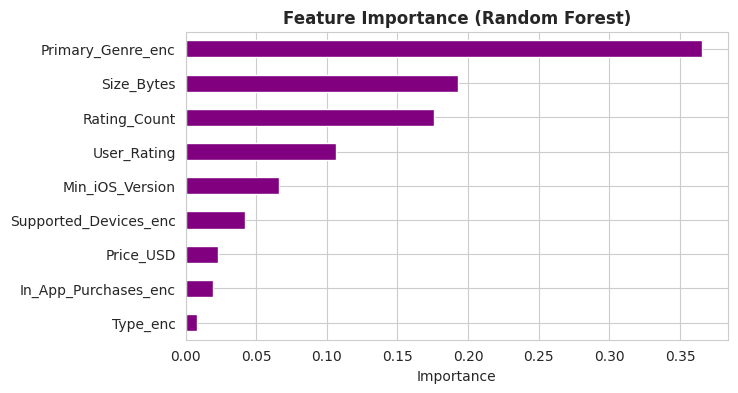

In [36]:
importances = pd.Series(models["Random Forest"].feature_importances_, index=feature_cols)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(7,4))
importances.plot(kind='barh', color='purple')
plt.title("Feature Importance (Random Forest)",fontweight='bold')
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.show()

## **10. Conclusion**

- **Best model:** Random Forest achieved the highest accuracy (~60%) and F1-score, clearly beating the majority-class baseline (~53%).
- **Key insight:** `Primary_Genre` is by far the most important feature — genres like *Finance* and *Social Networking* are almost never rated 4+ or 9+, giving the model a genuine, learnable pattern. `Size_Bytes`, `Rating_Count`, and `User_Rating` add smaller, supporting signal.
- **Honest note on accuracy:** Columns like `Price_USD` and `Type` looked promising at first glance but showed **no real relationship** with Content Rating during EDA (near-random AUC) — a good reminder to always check a feature's actual signal (via correlation/feature importance) before trusting it, rather than assuming more features = better model.
- **Next steps:** Try hyperparameter tuning (GridSearchCV), combine genre with text features from `Genres`, or use SMOTE if class imbalance across ratings becomes a bigger issue in a larger dataset.

---

> **If you have found this notebook helpful, Please Upvote!**

